# 주별 누적 재구매확률 예측 (Discrete-Time Survival)

**입력:** `data/processed/pp_train|pp_val|pp_test.parquet` (person-period 포맷)

**모델링 구조**
- 행 단위 타깃 `y` = "해당 주차에 **최초** 재구매했는가" → 이산시간 hazard $h(t\mid x)$
- 누적 재구매확률 $F(t) = 1 - \prod_{s\le t}\bigl(1 - h(s)\bigr)$ → **단조증가 자동 보장**
- 학습/검증은 **이벤트 주차에서 절단된** 위험집합, 예측은 **4주 전체 그리드**

**평가 이원화**
| 층위 | 데이터 | 타깃 | 지표 |
|---|---|---|---|
| 주차(hazard) | 절단본 | `y` | AUC, PR-AUC, LogLoss, Brier |
| 고객(4주 누적) | 전체 그리드 | `event` | AUC, Brier, 보정곡선, 십분위 lift |

> `pp_test`는 `truncate=False`로 저장되어 있으므로 **주차 지표용 절단본을 이 노트북에서 다시 만든다.**

In [89]:
# ============================================================
# 0. 환경 설정
# ============================================================
# 필요시: pip install lightgbm
import warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 50)

DATA_DIR = Path('data/processed')
OUT_DIR  = Path('data/model');  OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR  = Path('reports/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)

N_WEEKS = 4
SEED = 42
rng = np.random.default_rng(SEED)

print('설정 완료')

설정 완료


## 1. 적재 및 무결성 검증 / 실험용 칼럼 선택

저장 단계에서 `Customer ID`가 문자열로 변환되어 있고 `origin`은 `'YYYY-MM'` 문자열이다.
아래 검증을 **전부 통과해야** 다음 단계로 넘어간다.

In [90]:
# ============================================================
# 1. 적재
# ============================================================
def load_pp(name):
    d = pd.read_parquet(DATA_DIR / f'{name}.parquet')
    d['Customer ID'] = d['Customer ID'].astype(str)
    d['origin'] = d['origin'].astype(str)
    return d

pp_train = load_pp('pp_train')
pp_val   = load_pp('pp_val')
pp_test  = load_pp('pp_test')

for nm, d in [('train', pp_train), ('val', pp_val), ('test', pp_test)]:
    print(f'{nm:5s} {d.shape}  origin: {sorted(d["origin"].unique())}')

print('\n칼럼:', list(pp_train.columns))

# ============================================================
# 2. 실험용 피처 선택 (파일은 23개 다 들고 있음 / 여기서 골라 씀)
# ============================================================
BASE = ['Recency', 'Frequency', 'Monetary',
        'sales_lag_1', 
        'sales_lag_2', 'sales_lag_3',
        'orders_lag_1', 'orders_lag_2', 'orders_lag_3',
        'quantity_lag_1', 'customer_tenure',
        'Segment', 'week', 'pred_month']

# 실험 단계별 추가 세트
ADD_1 = ['avg_order_value', 'last_order_value', 'std_order_value']
ADD_2 = ['max_order_value', 'avg_purchase_qty', 'sales_per_tenure']
# sales_30d / 'sales_trend_1m' / 'sales_90d 중복이라 제외

MODEL_FEATS = BASE    # ← 기준선. 1차는 BASE + ADD_1 로 바꿔가며 실험
CAT_FEATS   = ['Segment']     # CatBoost 범주형

# 파일에 실제 있는지 방어
missing = [c for c in MODEL_FEATS if c not in pp_train.columns]
assert not missing, f'파일에 없는 피처: {missing}'

train (260439, 30)  origin: ['2010-03', '2010-04', '2010-05', '2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08']
val   (19847, 30)  origin: ['2011-09']
test  (22476, 30)  origin: ['2011-10']

칼럼: ['Customer ID', 'origin', 'split', 'Recency', 'Frequency', 'Monetary', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'orders_lag_1', 'orders_lag_2', 'orders_lag_3', 'quantity_lag_1', 'customer_tenure', 'Segment', 'week', 'pred_month', 'month', 'avg_order_value', 'sales_30d', 'sales_90d', 'last_order_value', 'max_order_value', 'std_order_value', 'sales_trend_1m', 'avg_purchase_qty', 'sales_per_tenure', 'y', 'event', 'week_of_repurchase']


In [91]:

# ============================================================
# 2. 무결성 검증 (실패 시 즉시 중단)
# ============================================================
EXPECTED_SHAPE = {'train': (260439, 30), 'val': (19847, 30), 'test': (22476, 30)}

KEYS  = ['Customer ID', 'origin', 'split']
FEATS = ['Recency', 'Frequency', 'Monetary',
         'sales_lag_1', 'sales_lag_2', 'sales_lag_3',
         'orders_lag_1', 'orders_lag_2', 'orders_lag_3',
         'quantity_lag_1', 'customer_tenure', 'month',
         # ── 파생 9개 전부 (파일 스키마) ──
         'avg_order_value', 'sales_30d', 'sales_90d',
         'last_order_value', 'max_order_value', 'std_order_value',
         'sales_trend_1m', 'avg_purchase_qty', 'sales_per_tenure',
         'Segment', 'week', 'pred_month']
LABEL = ['y', 'event', 'week_of_repurchase']

for nm, d in [('train', pp_train), ('val', pp_val), ('test', pp_test)]:
    assert d.shape == EXPECTED_SHAPE[nm], f'{nm} 형태 불일치: {d.shape}'
    assert set(KEYS + FEATS + LABEL) == set(d.columns), f'{nm} 칼럼 불일치'
    # 키 유일성: (고객, origin, 주차)
    assert not d.duplicated(['Customer ID', 'origin', 'week']).any(), f'{nm} 키 중복'
    # 주차 범위
    assert d['week'].between(1, N_WEEKS).all(), f'{nm} week 범위 이상'
    # y는 고객-origin당 최대 1회
    assert d.groupby(['Customer ID', 'origin'])['y'].sum().max() <= 1, f'{nm} y 중복 발생'
    # 라벨 정합성: y=1인 행은 반드시 event=1 이고 week == week_of_repurchase
    pos = d[d['y'] == 1]
    assert (pos['event'] == 1).all() and (pos['week'] == pos['week_of_repurchase']).all(), f'{nm} 라벨 불일치'

# 누수 컬럼 잔존 확인
LEAK = ['target_next_purchase', 'target_next_sales', 'next_month_orders',
        'last_week', 'monthly_last_purchase', 'last_purchase_date', 'month_end']
assert not (set(LEAK) & set(pp_train.columns)), '누수 컬럼 잔존'
assert not (set(LABEL) & set(FEATS)), '라벨이 피처에 포함됨'

print('무결성 검증 통과')

무결성 검증 통과


In [92]:
declared = set(KEYS + FEATS + LABEL)   # 29개
for nm, d in [('train', pp_train), ('val', pp_val), ('test', pp_test)]:
    extra = sorted(set(d.columns) - declared)
    print(f'{nm}: {d.shape[1]}열, 여분 → {extra}')

train: 30열, 여분 → []
val: 30열, 여분 → []
test: 30열, 여분 → []


In [93]:
# ============================================================
# 3. 결측 / 분포 점검
# ============================================================
na = pd.DataFrame({
    'train': pp_train[FEATS].isna().mean(),
    'val':   pp_val[FEATS].isna().mean(),
    'test':  pp_test[FEATS].isna().mean(),
}).round(4)
print('결측률 확인(0인 행 생략)')
print(na[(na > 0).any(axis=1)])
# sales_lag_2/3, orders_lag_2/3 은 고객 초기 월에서 NaN → LightGBM이 결측 분기로 자체 처리

print('\n[주의] pred_month 분포 — split별 고유값')
for nm, d in [('train', pp_train), ('val', pp_val), ('test', pp_test)]:
    print(f'  {nm:5s}: {sorted(int(v) for v in d["pred_month"].unique())}')

print('\ntrain 내 pred_month별 origin 수 (test=11월의 학습 근거가 몇 개인지)')
print(pp_train.groupby('pred_month')['origin'].nunique().to_frame('n_origins').T)

결측률 확인(0인 행 생략)
               train     val    test
sales_lag_2   0.0500  0.0345  0.0390
sales_lag_3   0.1037  0.0537  0.0721
orders_lag_2  0.0500  0.0345  0.0390
orders_lag_3  0.1037  0.0537  0.0721

[주의] pred_month 분포 — split별 고유값
  train: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  val  : [10]
  test : [11]

train 내 pred_month별 origin 수 (test=11월의 학습 근거가 몇 개인지)
pred_month  1   2   3   4   5   6   7   8   9   10  11  12
n_origins    1   1   1   2   2   2   2   2   2   1   1   1


## 2. 절단본 생성 — 주차 지표 평가용

`pp_test`는 `truncate=False`(4주 전체)로 저장되어 있다.
2주차에 재구매한 고객의 3·4주차 행은 **위험집합에서 이미 이탈**한 관측치이므로,
그대로 두고 hazard 지표를 재면 음성 표본이 인위적으로 늘어 성능이 과대평가된다.

- **주차 hazard 평가** → 절단본 `pp_test_tr`
- **누적확률 산출** → 전체 그리드 `pp_test`

In [94]:
# ============================================================
# 4. 절단 함수
# ============================================================
# 이벤트 주차까지만 남긴다(=위험집합). 학습/검증 저장본과 동일한 규칙.
def truncate_pp(d, n_weeks=N_WEEKS):
    last_week = np.where(d['event'] == 1, d['week_of_repurchase'], n_weeks)
    return d.loc[d['week'] <= last_week].reset_index(drop=True)

# 테스트 데이터를 올바른 위험집합 형태로 절단
pp_test_tr = truncate_pp(pp_test)

# 저장본(train/val)은 이미 절단되어 있는지 역검증
assert len(truncate_pp(pp_train)) == len(pp_train), 'pp_train 절단 상태 불일치'
assert len(truncate_pp(pp_val))   == len(pp_val),   'pp_val 절단 상태 불일치'

print(f'test 전체 그리드 : {len(pp_test):,}행  (hazard {pp_test["y"].mean():.4f}  ← 편향)')
print(f'test 절단본      : {len(pp_test_tr):,}행  (hazard {pp_test_tr["y"].mean():.4f}  ← 올바름)')
print(f'제거된 사후 행   : {len(pp_test) - len(pp_test_tr):,}행')

print('\nsplit별 요약')
summary = pd.DataFrame([
    dict(split='train', rows=len(pp_train), cust=pp_train['Customer ID'].nunique(),
         hazard=pp_train['y'].mean()),
    dict(split='val',   rows=len(pp_val),   cust=pp_val['Customer ID'].nunique(),
         hazard=pp_val['y'].mean()),
    dict(split='test',  rows=len(pp_test_tr), cust=pp_test_tr['Customer ID'].nunique(),
         hazard=pp_test_tr['y'].mean()),
]).round(4)
print(summary)

test 전체 그리드 : 22,476행  (hazard 0.0618  ← 편향)
test 절단본      : 20,112행  (hazard 0.0691  ← 올바름)
제거된 사후 행   : 2,364행

split별 요약
   split    rows  cust  hazard
0  train  260439  5218  0.0551
1    val   19847  5401  0.0530
2   test   20112  5619  0.0691


In [95]:
# ============================================================
# 5. 고객 단위 정답 (4주 내 재구매 여부)
# ============================================================
def customer_truth(d):
    return (d.groupby(['Customer ID', 'origin'], as_index=False)
              .agg(event=('event', 'max'),
                   week_of_repurchase=('week_of_repurchase', 'max')))

truth_test = customer_truth(pp_test)
truth_val  = customer_truth(pp_val)#데이터프레임 변수에 저장

print(f'test 고객수 {len(truth_test):,}  |  4주 내 재구매율 {truth_test["event"].mean():.4f}')
print(f'val  고객수 {len(truth_val):,}  |  4주 내 재구매율 {truth_val["event"].mean():.4f}')

print('\ntest 최초 재구매 주차 분포')
print(truth_test.loc[truth_test['event'] == 1, 'week_of_repurchase']
      .value_counts().sort_index().to_frame('n'))

test 고객수 5,619  |  4주 내 재구매율 0.2474
val  고객수 5,401  |  4주 내 재구매율 0.1948

test 최초 재구매 주차 분포
                      n
week_of_repurchase     
1.0                 400
2.0                 401
3.0                 362
4.0                 227


## 3. 피처 준비(모델에 넣을 입력 데이터(X)와 정답(y)을 만드는 전처리 코드)

- `Segment`, `week`, `pred_month`는 범주형으로 취급 (`week`는 주차별 기저 hazard, `Segment`는 RFM 군집)
- 범주 목록은 **train 기준**으로 고정해 split 간 인코딩 어긋남을 막는다
- 불균형 보정(`is_unbalance`, `scale_pos_weight`, 오버샘플링)은 **쓰지 않는다** — 누적확률의 절대 수준이 곧 산출물이라 보정을 깨면 안 된다

In [96]:
# ============================================================
# 6. 피처 행렬
# ============================================================
CAT = [c for c in ['Segment', 'week', 'pred_month'] if c in MODEL_FEATS]   # ← MODEL_FEATS 기준
NUM = [c for c in MODEL_FEATS if c not in CAT]                             # ← FEATS → MODEL_FEATS

CAT_LEVELS = {c: sorted(pd.unique(pp_train[c].dropna())) for c in CAT}
for c, lv in CAT_LEVELS.items():
    print(f'{c:12s} ({len(lv)}): {[v.item() if hasattr(v, "item") else v for v in lv]}')

def make_X(d, feats=MODEL_FEATS):      # ← FEATS → MODEL_FEATS (핵심)
    X = d[feats].copy()
    for c in CAT:
        if c in X.columns:
            X[c] = pd.Categorical(X[c], categories=CAT_LEVELS[c])
    for c in [x for x in feats if x not in CAT]:
        X[c] = X[c].astype('float32')
    return X

X_tr, y_tr = make_X(pp_train), pp_train['y'].values
X_va, y_va = make_X(pp_val),   pp_val['y'].values
X_te_tr, y_te_tr = make_X(pp_test_tr), pp_test_tr['y'].values
X_te_full = make_X(pp_test)

for c in CAT:
    n_nan = X_te_full[c].isna().sum() - pp_test[c].isna().sum()
    assert n_nan == 0, f'{c}: test에 미학습 범주 {n_nan}건'

print(f'\nX_tr {X_tr.shape} | X_va {X_va.shape} | X_te(절단) {X_te_tr.shape} | X_te(전체) {X_te_full.shape}')

Segment      (4): ['At Risk', 'Champions', 'Lost', 'New / Promising']
week         (4): [1, 2, 3, 4]
pred_month   (12): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

X_tr (260439, 14) | X_va (19847, 14) | X_te(절단) (20112, 14) | X_te(전체) (22476, 14)


## 4. 베이스라인

논문 심사에서 "그래서 모델이 뭘 더 했는가"를 방어하려면 **동일한 누적확률 산식**을 쓰는 단순 대조군이 필요하다.

| 이름 | 정의 |
|---|---|
| B0 | 주차별 전체 평균 hazard (개인차 없음) |
| B1 | `Segment × week` 경험 hazard (RFM 군집만 사용) |
| B2 | 로지스틱 회귀 (선형 기저) |

In [97]:
# ============================================================
# 7. B0 / B1 — 경험 hazard 베이스라인 (train 절단본에서 추정)
# ============================================================
h_week = pp_train.groupby('week')['y'].mean()
h_seg  = pp_train.groupby(['Segment', 'week'])['y'].mean()

print('B0: 주차별 평균 hazard')
print(h_week.round(4).to_frame('hazard').T)
print('\nB1: Segment × week hazard')
print(h_seg.unstack().round(4))

# B0: 주차별 평균만 사용
# B1: 세그먼트별·주차별 평균 사용
# 둘 다 복잡한 모델 학습 없이 train 평균을 그대로 활용하는 기준 모델

def predict_b0(d):
    return d['week'].map(h_week).values

def predict_b1(d):
    idx = pd.MultiIndex.from_arrays([d['Segment'], d['week']])
    p = h_seg.reindex(idx).to_numpy()
    fallback = d['week'].map(h_week).to_numpy()      # 미관측 조합은 주차 평균으로
    return np.where(np.isnan(p), fallback, p)


B0: 주차별 평균 hazard
week         1       2       3       4
hazard  0.0594  0.0584  0.0535  0.0478

B1: Segment × week hazard
week                  1       2       3       4
Segment                                        
At Risk          0.0522  0.0562  0.0552  0.0503
Champions        0.1800  0.1750  0.1633  0.1411
Lost             0.0202  0.0211  0.0191  0.0202
New / Promising  0.0533  0.0603  0.0604  0.0584


In [98]:
# ============================================================
# 8. B2 — 로지스틱 회귀
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# 금액/빈도는 우편향이 심하므로 log1p 후 표준화 (음수 방어: clip)
num_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(lambda a: np.log1p(np.clip(a, 0, None)))),
    ('sc',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

logit = Pipeline([
    ('prep', ColumnTransformer([('num', num_pipe, NUM), ('cat', cat_pipe, CAT)])),
    ('clf',  LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)),
])

logit.fit(pp_train[FEATS].assign(**{c: pp_train[c].astype(str) for c in CAT}), y_tr)

def predict_b2(d):
    return logit.predict_proba(
        d[FEATS].assign(**{c: d[c].astype(str) for c in CAT}))[:, 1]

print('B2 학습 완료 | val hazard 예측 평균:', predict_b2(pp_val).mean().round(4))

B2 학습 완료 | val hazard 예측 평균: 0.0746


## 5. 주모델 — LightGBM hazard

`week`를 피처에 포함시켰으므로 하나의 모델이 주차별 기저 hazard와 개인 효과를 동시에 학습한다.
조기종료 기준은 **LogLoss**(보정 지향), 참고로 AUC도 함께 본다.

In [99]:
# ============================================================
# 9. LightGBM 학습
# ============================================================
import lightgbm as lgb

params = dict(
    objective='binary',
    metric=['binary_logloss', 'auc'],
    learning_rate=0.03,
    num_leaves=63,
    min_data_in_leaf=300,      # hazard 5% 수준 → 리프당 최소 표본 확보
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=1,
    lambda_l2=5.0,
    max_cat_to_onehot=8,
    verbosity=-1,
    seed=SEED,
    # is_unbalance / scale_pos_weight 미사용 — 확률 보정 유지
)

dtr = lgb.Dataset(X_tr, y_tr, categorical_feature=CAT, free_raw_data=False)
dva = lgb.Dataset(X_va, y_va, categorical_feature=CAT, reference=dtr, free_raw_data=False)

model = lgb.train(
    params, dtr,
    num_boost_round=3000,
    valid_sets=[dtr, dva],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(150, verbose=True), lgb.log_evaluation(200)],
)

BEST_ITER = model.best_iteration
print(f'\nbest_iteration = {BEST_ITER}')

Training until validation scores don't improve for 150 rounds
[200]	train's binary_logloss: 0.176902	train's auc: 0.800321	val's binary_logloss: 0.185002	val's auc: 0.750567
Early stopping, best iteration is:
[131]	train's binary_logloss: 0.179224	train's auc: 0.792	val's binary_logloss: 0.184713	val's auc: 0.753218

best_iteration = 131


In [100]:
# ============================================================
# 10. hazard 예측
# ============================================================
def predict_lgb(X):
    return model.predict(X, num_iteration=BEST_ITER)

pred = {
    'val':      {'B0': predict_b0(pp_val),   'B1': predict_b1(pp_val),
                 'B2': predict_b2(pp_val),   'LGBM': predict_lgb(X_va)},
    'test_tr':  {'B0': predict_b0(pp_test_tr), 'B1': predict_b1(pp_test_tr),
                 'B2': predict_b2(pp_test_tr), 'LGBM': predict_lgb(X_te_tr)},
    'test_full':{'B0': predict_b0(pp_test),  'B1': predict_b1(pp_test),
                 'B2': predict_b2(pp_test),  'LGBM': predict_lgb(X_te_full)},
}

print('test 절단본 hazard 예측 평균 vs 실제(test 절단본의 고객-주차 행 기준 평균 hazard) :', pp_test_tr['y'].mean().round(4))
for k, v in pred['test_tr'].items():
    print(f'  {k:5s}: {v.mean():.4f}')

test 절단본 hazard 예측 평균 vs 실제(test 절단본의 고객-주차 행 기준 평균 hazard) : 0.0691
  B0   : 0.0552
  B1   : 0.0601
  B2   : 0.0765
  LGBM : 0.0652


## 6. 평가 ① — 주차 hazard (절단본)

In [101]:
# ============================================================
# 11. 주차 단위 지표
# ============================================================
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             log_loss, brier_score_loss)

def hazard_metrics(y, p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return dict(n=len(y), pos=int(y.sum()), base=y.mean(),
                AUC=roc_auc_score(y, p),
                PR_AUC=average_precision_score(y, p),
                LogLoss=log_loss(y, p),
                Brier=brier_score_loss(y, p))

rows = []
for split, yy in [('val', y_va), ('test', y_te_tr)]:
    key = 'val' if split == 'val' else 'test_tr'
    for mdl, p in pred[key].items():
        rows.append(dict(split=split, model=mdl, **hazard_metrics(yy, p)))

hz = pd.DataFrame(rows).set_index(['split', 'model']).round(4)
print(hz)

                 n   pos    base     AUC  PR_AUC  LogLoss   Brier
split model                                                      
val   B0     19847  1052  0.0530  0.5265  0.0566   0.2071  0.0502
      B1     19847  1052  0.0530  0.7095  0.1126   0.1924  0.0486
      B2     19847  1052  0.0530  0.7491  0.1875   0.1889  0.0481
      LGBM   19847  1052  0.0530  0.7532  0.1947   0.1847  0.0468
test  B0     20112  1390  0.0691  0.5269  0.0724   0.2526  0.0645
      B1     20112  1390  0.0691  0.7091  0.1453   0.2326  0.0615
      B2     20112  1390  0.0691  0.7548  0.2403   0.2210  0.0588
      LGBM   20112  1390  0.0691  0.7627  0.2484   0.2186  0.0585


In [102]:
# ============================================================
# 12. 주차별 hazard 보정 확인 (test)
# ============================================================
chk = pp_test_tr[['week', 'y']].copy()
chk['pred'] = pred['test_tr']['LGBM']
tab = chk.groupby('week').agg(n=('y', 'size'), 실제=('y', 'mean'), 예측=('pred', 'mean'))
tab['비율'] = (tab['예측'] / tab['실제']).round(3)
print(tab.round(4))

         n      실제      예측     비율
week                             
1     5619  0.0712  0.0665  0.935
2     5219  0.0768  0.0699  0.909
3     4818  0.0751  0.0633  0.843
4     4456  0.0509  0.0599  1.176


## 7. 평가 ② — 고객 단위 4주 누적확률

$$S(t)=\prod_{s=1}^{t}\bigl(1-\hat h(s)\bigr),\qquad F(t)=1-S(t)$$

생존함수 정의S(t) : t주까지 아직 재구매하지 않을 확률  
주차별 재구매 확률(hazard)을 누적해서, t주 이내 재구매할 확률로 바꾸는 모델  
  
hazard가 $[0,1]$이므로 $F(t)$는 **정의상 단조증가**한다(사후 보정 불필요).

In [103]:
# ============================================================
# 13. 누적확률 산출
# ============================================================
# person-period 전체 그리드 -> 주차별 누적 재구매확률
def cumulative(d, hazard, n_weeks=N_WEEKS):
    out = d[['Customer ID', 'origin', 'week']].copy()
    out['h'] = np.clip(hazard, 1e-9, 1 - 1e-9)
    out = out.sort_values(['Customer ID', 'origin', 'week'])

    # 고객별 4주 전체가 있어야 누적곱이 성립
    cnt = out.groupby(['Customer ID', 'origin'])['week'].size()
    assert (cnt == n_weeks).all(), '전체 그리드가 아님 — truncate=False 데이터를 넣어야 함'

    g = out.groupby(['Customer ID', 'origin'], sort=False)
    out['S'] = g['h'].transform(lambda s: (1 - s).cumprod())
    out['F'] = 1 - out['S']
    return out.reset_index(drop=True)

cum = {m: cumulative(pp_test, p) for m, p in pred['test_full'].items()}

# 단조성 검증
for m, c in cum.items():
    d = c.groupby(['Customer ID', 'origin'])['F'].diff().dropna()
    assert (d >= -1e-12).all(), f'{m}: 누적확률 단조성 위반'
print('단조증가 검증 통과')

cum['LGBM'].head(8).round(4)

단조증가 검증 통과


,Customer ID,origin,week,h,S,F
0,12346,2011-10,1,0.0291,0.9709,0.0291
1,12346,2011-10,2,0.0315,0.9403,0.0597
2,12346,2011-10,3,0.0315,0.9106,0.0894
3,12346,2011-10,4,0.0307,0.8827,0.1173
4,12347,2011-10,1,0.0541,0.9459,0.0541
5,12347,2011-10,2,0.0829,0.8675,0.1325
6,12347,2011-10,3,0.0864,0.7925,0.2075
7,12347,2011-10,4,0.0905,0.7208,0.2792


In [104]:
# ============================================================
# 14. 고객 단위 지표 (4주 누적 vs 실제 event)
# ============================================================
def customer_scores(c, truth, n_weeks=N_WEEKS):
    f4 = c.loc[c['week'] == n_weeks, ['Customer ID', 'origin', 'F']]
    m = truth.merge(f4, on=['Customer ID', 'origin'], how='left', validate='one_to_one')
    assert m['F'].notna().all(), '누적확률 결측'
    return m

rows, cust = [], {}
for m, c in cum.items():
    s = customer_scores(c, truth_test)
    cust[m] = s
    rows.append(dict(model=m, n=len(s), 실제=s['event'].mean(), 예측=s['F'].mean(),
                     AUC=roc_auc_score(s['event'], s['F']),
                     PR_AUC=average_precision_score(s['event'], s['F']),
                     LogLoss=log_loss(s['event'], np.clip(s['F'], 1e-6, 1 - 1e-6)),
                     Brier=brier_score_loss(s['event'], s['F'])))

cust_tbl = pd.DataFrame(rows).set_index('model').round(4)
print('=== test 고객 단위 (4주 누적) ===')
print(cust_tbl)

=== test 고객 단위 (4주 누적) ===
          n      실제      예측     AUC  PR_AUC  LogLoss   Brier
model                                                       
B0     5619  0.2474  0.2018  0.5000  0.2474   0.5655  0.1883
B1     5619  0.2474  0.2189  0.7248  0.4292   0.4959  0.1613
B2     5619  0.2474  0.2673  0.7765  0.5856   0.4583  0.1473
LGBM   5619  0.2474  0.2404  0.7846  0.5975   0.4500  0.1446


고객별 차이를 전혀 구분하지 않고 전체 평균 재구매율만 예측했을 때 발생하는 확률 오차 수준

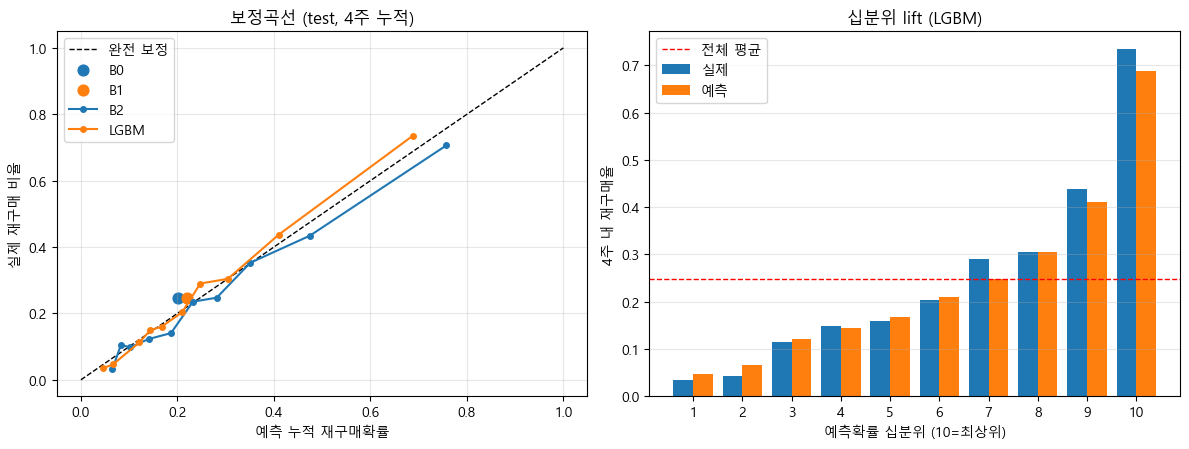

          n      실제      예측
decile                     
1       562  0.0356  0.0466
2       562  0.0427  0.0659
3       562  0.1157  0.1212
4       562  0.1495  0.1437
5       562  0.1601  0.1674
6       561  0.2032  0.2095
7       562  0.2900  0.2475
8       562  0.3043  0.3046
9       562  0.4377  0.4103
10      562  0.7349  0.6875

상위 10% lift: 2.97배


In [105]:
# ============================================================
# 15. 보정곡선 + 십분위 lift
# ============================================================
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='완전 보정')
for m in ['B0', 'B1', 'B2', 'LGBM']:
    s = cust[m]
    if s['F'].nunique() < 5:
        ax.scatter([s['F'].mean()], [s['event'].mean()], s=60, label=m)
        continue
    pt, pp_ = calibration_curve(s['event'], s['F'], n_bins=10, strategy='quantile')
    ax.plot(pp_, pt, 'o-', ms=4, label=m)
ax.set_xlabel('예측 누적 재구매확률'); ax.set_ylabel('실제 재구매 비율')
ax.set_title('보정곡선 (test, 4주 누적)'); ax.legend(); ax.grid(alpha=.3)

ax = axes[1]
s = cust['LGBM'].copy()
s['decile'] = pd.qcut(s['F'].rank(method='first'), 10, labels=range(1, 11))
lift = s.groupby('decile').agg(n=('event', 'size'), 실제=('event', 'mean'), 예측=('F', 'mean'))
x = np.arange(1, 11)
ax.bar(x - 0.2, lift['실제'], 0.4, label='실제')
ax.bar(x + 0.2, lift['예측'], 0.4, label='예측')
ax.axhline(s['event'].mean(), color='r', ls='--', lw=1, label='전체 평균')
ax.set_xticks(x); ax.set_xlabel('예측확률 십분위 (10=최상위)'); ax.set_ylabel('4주 내 재구매율')
ax.set_title('십분위 lift (LGBM)'); ax.legend(); ax.grid(alpha=.3, axis='y')

plt.tight_layout(); plt.savefig(FIG_DIR / 'calibration_lift.png', dpi=150); plt.show()

print(lift.round(4))
print(f"\n상위 10% lift: {lift.loc[10,'실제'] / s['event'].mean():.2f}배")

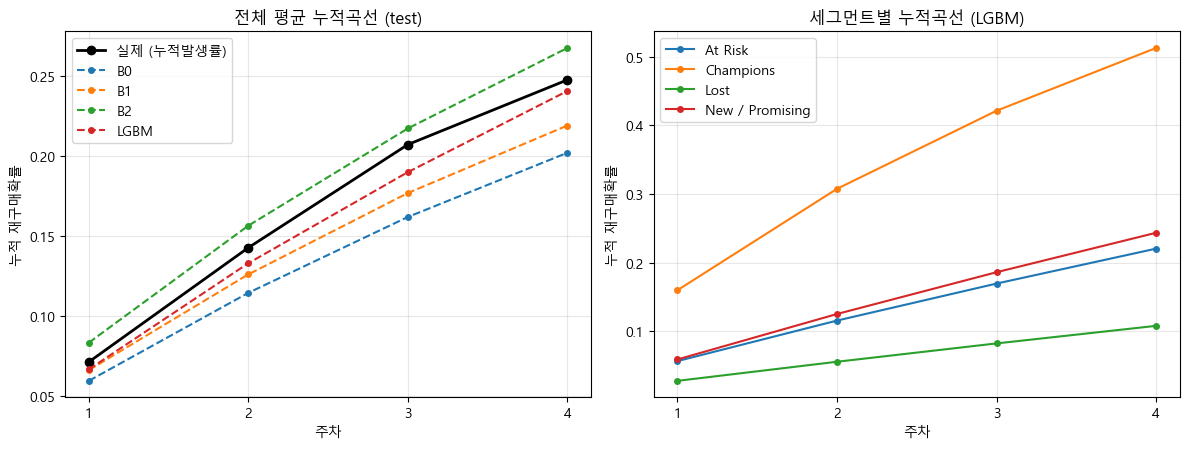

   week      실제    LGBM
0     1  0.0712  0.0665
1     2  0.1426  0.1328
2     3  0.2070  0.1898
3     4  0.2474  0.2404


In [106]:
# ============================================================
# 16. 주차별 누적곡선 — 예측 vs 실제
# ============================================================
obs = [((truth_test['event'] == 1) &
        (truth_test['week_of_repurchase'] <= t)).mean() for t in range(1, N_WEEKS + 1)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ax = axes[0]
ax.plot(range(1, N_WEEKS + 1), obs, 'ko-', lw=2, label='실제 (누적발생률)')
for m in ['B0', 'B1', 'B2', 'LGBM']:
    ax.plot(range(1, N_WEEKS + 1),
            cum[m].groupby('week')['F'].mean().values, 'o--', ms=4, label=m)
ax.set_xticks(range(1, N_WEEKS + 1))
ax.set_xlabel('주차'); ax.set_ylabel('누적 재구매확률')
ax.set_title('전체 평균 누적곡선 (test)'); ax.legend(); ax.grid(alpha=.3)

ax = axes[1]
seg_map = pp_test.drop_duplicates(['Customer ID', 'origin'])[['Customer ID', 'origin', 'Segment']]
cs = cum['LGBM'].merge(seg_map, on=['Customer ID', 'origin'])
for seg, g in cs.groupby('Segment'):
    ax.plot(range(1, N_WEEKS + 1), g.groupby('week')['F'].mean().values, 'o-', ms=4, label=seg)
ax.set_xticks(range(1, N_WEEKS + 1))
ax.set_xlabel('주차'); ax.set_ylabel('누적 재구매확률')
ax.set_title('세그먼트별 누적곡선 (LGBM)'); ax.legend(); ax.grid(alpha=.3)

plt.tight_layout(); plt.savefig(FIG_DIR / 'cumulative_curves.png', dpi=150); plt.show()

print(pd.DataFrame({'week': range(1, N_WEEKS + 1), '실제': obs,
                    'LGBM': cum['LGBM'].groupby('week')['F'].mean().values}).round(4))

## 8. 진단

### 8-1. `pred_month` 앰블레이션 (⚠️ 중요)

월말 origin + 28일 창 구조상 `pred_month`는 **origin당 한 값**이다.
따라서 test에서는 항상 `11`로 **분산이 0**이며, 학습 근거는 origin `2010-10` **단 하나**다.

- AUC는 영향을 받지 않는다(상수이므로 순위 불변)
- 그러나 **누적확률의 절대 수준(보정)** 은 이 한 origin에 통째로 의존한다

넣은 모델과 뺀 모델을 모두 학습해 지표를 병기하는 것이 방어 가능한 서술이다.

In [107]:
# ============================================================
# 17. pred_month 앰블레이션
# ============================================================
FEATS_NO_PM = [f for f in FEATS if f != 'pred_month']

dtr2 = lgb.Dataset(make_X(pp_train, FEATS_NO_PM), y_tr,
                   categorical_feature=['Segment', 'week'], free_raw_data=False)
dva2 = lgb.Dataset(make_X(pp_val, FEATS_NO_PM), y_va,
                   categorical_feature=['Segment', 'week'], reference=dtr2, free_raw_data=False)

model_no_pm = lgb.train(params, dtr2, num_boost_round=3000,
                        valid_sets=[dva2], valid_names=['val'],
                        callbacks=[lgb.early_stopping(150, verbose=False),
                                   lgb.log_evaluation(0)])

p_te_tr_no = model_no_pm.predict(make_X(pp_test_tr, FEATS_NO_PM),
                                 num_iteration=model_no_pm.best_iteration)
p_te_fu_no = model_no_pm.predict(make_X(pp_test, FEATS_NO_PM),
                                 num_iteration=model_no_pm.best_iteration)

cum_no = cumulative(pp_test, p_te_fu_no)
s_no = customer_scores(cum_no, truth_test)

abl = pd.DataFrame([
    dict(model='LGBM (+pred_month)',
         주차AUC=roc_auc_score(y_te_tr, pred['test_tr']['LGBM']),
         주차LogLoss=log_loss(y_te_tr, np.clip(pred['test_tr']['LGBM'], 1e-6, 1 - 1e-6)),
         고객AUC=cust_tbl.loc['LGBM', 'AUC'],
         고객Brier=cust_tbl.loc['LGBM', 'Brier'],
         예측평균=cust['LGBM']['F'].mean()),
    dict(model='LGBM (-pred_month)',
         주차AUC=roc_auc_score(y_te_tr, p_te_tr_no),
         주차LogLoss=log_loss(y_te_tr, np.clip(p_te_tr_no, 1e-6, 1 - 1e-6)),
         고객AUC=roc_auc_score(s_no['event'], s_no['F']),
         고객Brier=brier_score_loss(s_no['event'], s_no['F']),
         예측평균=s_no['F'].mean()),
]).set_index('model').round(4)

abl['실제평균'] = truth_test['event'].mean().round(4)
print(abl)
print('\n→ AUC 차이가 미미하고 예측평균만 움직이면, pred_month는 계절 절편으로만 작동한 것.')

                     주차AUC  주차LogLoss   고객AUC  고객Brier    예측평균    실제평균
model                                                                 
LGBM (+pred_month)  0.7627     0.2186  0.7846   0.1446  0.2404  0.2474
LGBM (-pred_month)  0.7594     0.2214  0.7819   0.1478  0.2198  0.2474

→ AUC 차이가 미미하고 예측평균만 움직이면, pred_month는 계절 절편으로만 작동한 것.


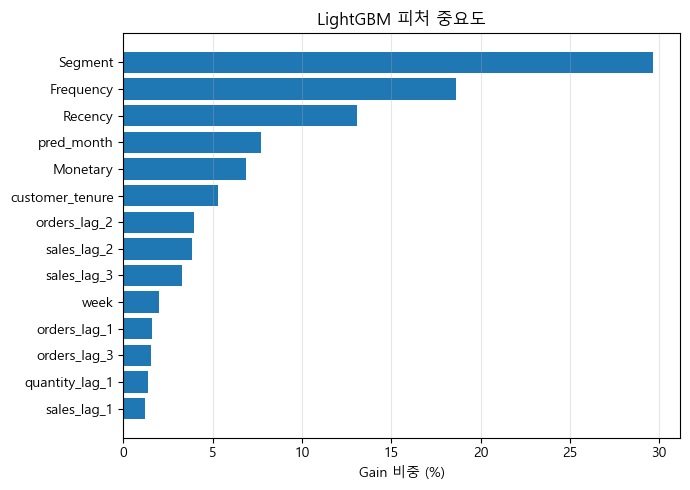

            feature  gain_pct  split
0           Segment     29.69     93
1         Frequency     18.65    744
2           Recency     13.08   1308
3        pred_month      7.69   1105
4          Monetary      6.84    962
5   customer_tenure      5.27    848
6      orders_lag_2      3.96    114
7       sales_lag_2      3.83    634
8       sales_lag_3      3.28    624
9              week      1.97    574
10     orders_lag_1      1.58    176
11     orders_lag_3      1.55    117
12   quantity_lag_1      1.36    448
13      sales_lag_1      1.23    375


In [108]:
# ============================================================
# 18. 피처 중요도
# ============================================================
imp = (pd.DataFrame({'feature': model.feature_name(),
                     'gain': model.feature_importance('gain'),
                     'split': model.feature_importance('split')})
       .sort_values('gain', ascending=False).reset_index(drop=True))
imp['gain_pct'] = (imp['gain'] / imp['gain'].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp['feature'][::-1], imp['gain_pct'][::-1])
ax.set_xlabel('Gain 비중 (%)'); ax.set_title('LightGBM 피처 중요도')
ax.grid(alpha=.3, axis='x')
plt.tight_layout(); plt.savefig(FIG_DIR / 'feature_importance.png', dpi=150); plt.show()

print(imp[['feature', 'gain_pct', 'split']])

### 8-2. 유의성 검정

LSTM 수요예측에서 쓴 **Diebold-Mariano는 여기 부적합**하다. DM은 시계열 예측오차의 자기상관을 다루는 검정이고,
여기는 고객 단위 이진 분류다. 대신:

- **페어드 부트스트랩** — 고객 단위 재표집으로 $\Delta$Brier / $\Delta$LogLoss 의 신뢰구간
- 필요하면 AUC 차이는 **DeLong 검정**

고객 단위로 재표집해야 한다(주차 행 단위로 하면 같은 고객의 4행이 독립으로 취급되어 CI가 과소추정된다).

In [109]:
# ============================================================
# 19. 페어드 부트스트랩 (고객 단위 재표집)
# ============================================================
def paired_bootstrap(base_model, comp_model, n_boot=2000, seed=SEED):
    a = cust[base_model].sort_values(['Customer ID', 'origin']).reset_index(drop=True)
    b = cust[comp_model].sort_values(['Customer ID', 'origin']).reset_index(drop=True)
    assert (a['Customer ID'].values == b['Customer ID'].values).all()

    y = a['event'].values.astype(float)
    pa, pb = a['F'].values, b['F'].values
    r = np.random.default_rng(seed)
    n = len(y)

    d_brier, d_auc = [], []
    for _ in range(n_boot):
        i = r.integers(0, n, n)
        yi = y[i]
        if yi.min() == yi.max():
            continue
        d_brier.append(np.mean((pa[i] - yi) ** 2) - np.mean((pb[i] - yi) ** 2))
        d_auc.append(roc_auc_score(yi, pb[i]) - roc_auc_score(yi, pa[i]))

    def ci(v):
        v = np.array(v)
        return v.mean(), np.percentile(v, 2.5), np.percentile(v, 97.5)

    mb, lb, ub = ci(d_brier)
    ma, la, ua = ci(d_auc)
    return dict(비교=f'{comp_model} - {base_model}',
                ΔBrier=round(-mb, 5), Brier_CI=f'[{-ub:.5f}, {-lb:.5f}]',
                ΔAUC=round(ma, 4),    AUC_CI=f'[{la:.4f}, {ua:.4f}]')

bt = pd.DataFrame([paired_bootstrap('B0', 'LGBM'),
                   paired_bootstrap('B1', 'LGBM'),
                   paired_bootstrap('B2', 'LGBM')])
print('페어드 부트스트랩 (2000회, 고객 단위 재표집)')
print('ΔBrier 음수 = LGBM 개선 / CI가 0을 포함하지 않으면 유의')
print(bt.to_string(index=False))

페어드 부트스트랩 (2000회, 고객 단위 재표집)
ΔBrier 음수 = LGBM 개선 / CI가 0을 포함하지 않으면 유의
       비교   ΔBrier             Brier_CI   ΔAUC           AUC_CI
LGBM - B0 -0.04371 [-0.04825, -0.03899] 0.2849 [0.2707, 0.2983]
LGBM - B1 -0.01667 [-0.01938, -0.01404] 0.0598 [0.0499, 0.0703]
LGBM - B2 -0.00271 [-0.00449, -0.00110] 0.0081 [0.0017, 0.0151]


## 9. 산출물 저장

In [110]:
# ============================================================
# 20. 저장
# ============================================================
# (A) 고객 × 주차 누적확률
out_weekly = (cum['LGBM']
              .merge(seg_map, on=['Customer ID', 'origin'])
              .merge(truth_test, on=['Customer ID', 'origin'])
              .rename(columns={'h': 'hazard', 'S': 'survival', 'F': 'cum_prob'})
              [['Customer ID', 'origin', 'Segment', 'week',
                'hazard', 'survival', 'cum_prob', 'event', 'week_of_repurchase']])
out_weekly.to_parquet(OUT_DIR / 'repurchase_weekly_prob_test.parquet', index=False)
out_weekly.to_csv(OUT_DIR / 'repurchase_weekly_prob_test.csv',
                  index=False, encoding='utf-8-sig')

# (B) 고객 단위 4주 누적
cust['LGBM'].rename(columns={'F': 'cum_prob_4w'}).to_csv(
    OUT_DIR / 'repurchase_4w_prob_test.csv', index=False, encoding='utf-8-sig')

# (C) 성능 요약 + 모델
hz.to_csv(OUT_DIR / 'metrics_hazard.csv', encoding='utf-8-sig')
cust_tbl.to_csv(OUT_DIR / 'metrics_customer.csv', encoding='utf-8-sig')
abl.to_csv(OUT_DIR / 'metrics_ablation.csv', encoding='utf-8-sig')
model.save_model(str(OUT_DIR / 'lgbm_hazard.txt'), num_iteration=BEST_ITER)

json.dump({'best_iteration': int(BEST_ITER), 'n_weeks': N_WEEKS,
           'feats': FEATS, 'cat': CAT, 'params': {k: str(v) for k, v in params.items()}},
          open(OUT_DIR / 'model_config.json', 'w', encoding='utf-8'),
          ensure_ascii=False, indent=2)

print('저장 완료 →', OUT_DIR.resolve())
for p in sorted(OUT_DIR.iterdir()):
    print(' ', p.name)

저장 완료 → C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model
  lgbm_hazard.txt
  metrics_ablation.csv
  metrics_customer.csv
  metrics_hazard.csv
  model_config.json
  repurchase_4w_prob_test.csv
  repurchase_weekly_prob_test.csv
  repurchase_weekly_prob_test.parquet
  table_hazard_test.csv


## 10. 남은 과제

1. **원본 노트북 수정 3건**
   - `SEG_FIT_LAST`를 `'2011-08'`로 (val origin이 KMeans 적합에 참여 중)

   - `N_WEEKS=4`인데 남아 있는 "10주" 주석/마크다운 정리

2. **origin이 1개뿐인 val/test**
   현재 val·test 모두 단일 기준월이라 성능 추정치의 분산이 크다.
   `2011-07/08/09` 3개 origin을 rolling-origin으로 묶어 평균±표준편차로 보고하면 심사 방어력이 올라간다.

3. **train 내부 CV**
   동일 고객이 여러 origin에 등장하므로 `GroupKFold(Customer ID)` 또는 시간 기반 rolling-origin CV.
   무작위 KFold는 같은 고객이 fold 양쪽에 들어가 성능이 부풀려진다.

4. **BG/NBD 대조군**  
   이미 적합해 둔 BG/NBD로 `P(구매 ≥ 1 in 28일)`을 뽑아 5번째 베이스라인으로 추가하면
   "확률모형 대비 ML의 이득"을 정량화할 수 있다.  

5. **과소 추정 가설 검정** / **재구매확률 - 코호트** 연관 분석

In [111]:
FEATS_NO_SEG = [f for f in FEATS if f != 'Segment']
d1 = lgb.Dataset(make_X(pp_train, FEATS_NO_SEG), y_tr,
                 categorical_feature=['week','pred_month'], free_raw_data=False)
d2 = lgb.Dataset(make_X(pp_val, FEATS_NO_SEG), y_va,
                 categorical_feature=['week','pred_month'], reference=d1, free_raw_data=False)

m_ns = lgb.train(params, d1, 3000, valid_sets=[d2],
                 callbacks=[lgb.early_stopping(150, verbose=False), lgb.log_evaluation(0)])

s_ns = customer_scores(cumulative(pp_test,
        m_ns.predict(make_X(pp_test, FEATS_NO_SEG), num_iteration=m_ns.best_iteration)),
        truth_test)

print('고객 AUC   %.4f → %.4f' % (cust_tbl.loc['LGBM','AUC'],
                                  roc_auc_score(s_ns['event'], s_ns['F'])))
print('고객 Brier %.4f → %.4f' % (cust_tbl.loc['LGBM','Brier'],
                                  brier_score_loss(s_ns['event'], s_ns['F'])))

고객 AUC   0.7846 → 0.7831
고객 Brier 0.1446 → 0.1455


In [112]:
cust['LGBM_noSeg'] = s_ns
print(pd.DataFrame([paired_bootstrap('LGBM_noSeg', 'LGBM')]).to_string(index=False))

               비교   ΔBrier             Brier_CI   ΔAUC            AUC_CI
LGBM - LGBM_noSeg -0.00089 [-0.00158, -0.00020] 0.0015 [-0.0016, 0.0045]


In [113]:
seg_curve = cs.pivot_table(index='week', columns='Segment', values='F', aggfunc='mean')
seg_n = cs[cs['week']==1].groupby('Segment').size()
seg_obs = (pp_test.drop_duplicates(['Customer ID','origin'])
           .groupby('Segment')['event'].mean())

print(seg_curve.round(4))
print('\n고객수\n', seg_n)
print('\n4주 실제 재구매율\n', seg_obs.round(4))
print('\nChampions / Lost 배율:',
      round(seg_curve.loc[4,'Champions'] / seg_curve.loc[4,'Lost'], 2))

Segment  At Risk  Champions    Lost  New / Promising
week                                                
1         0.0562     0.1596  0.0273           0.0586
2         0.1153     0.3075  0.0552           0.1249
3         0.1693     0.4214  0.0819           0.1858
4         0.2202     0.5130  0.1076           0.2434

고객수
 Segment
At Risk            1698
Champions          1118
Lost               2053
New / Promising     750
dtype: int64

4주 실제 재구매율
 Segment
At Risk            0.2138
Champions          0.5438
Lost               0.0994
New / Promising    0.2867
Name: event, dtype: float64

Champions / Lost 배율: 4.77


In [114]:
# ============================================================
# 23. 정규화 완화 그리드 (선택 기준: val logloss)
# ============================================================
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss

seg_te = (pp_test.drop_duplicates(['Customer ID', 'origin'])
          [['Customer ID', 'origin', 'Segment', 'event']])
KEY = ['Customer ID', 'origin']

GRID = [
    dict(name='기준',   min_data_in_leaf=300, lambda_l2=5.0, num_leaves=63),
    dict(name='완화1',  min_data_in_leaf=100, lambda_l2=1.0, num_leaves=63),
    dict(name='완화2',  min_data_in_leaf=50,  lambda_l2=1.0, num_leaves=127),
    dict(name='완화3',  min_data_in_leaf=100, lambda_l2=0.0, num_leaves=31),
    dict(name='강화',   min_data_in_leaf=500, lambda_l2=10.0, num_leaves=31),
]

dtr_g = lgb.Dataset(X_tr, y_tr, categorical_feature=CAT, free_raw_data=False)
dva_g = lgb.Dataset(X_va, y_va, categorical_feature=CAT, reference=dtr_g, free_raw_data=False)

res, models = [], {}
for g in GRID:
    p = {**params, **{k: v for k, v in g.items() if k != 'name'}}
    m = lgb.train(p, dtr_g, 3000, valid_sets=[dva_g], valid_names=['val'],
                  callbacks=[lgb.early_stopping(150, verbose=False), lgb.log_evaluation(0)])
    models[g['name']] = m
    bi = m.best_iteration

    pv = m.predict(X_va, num_iteration=bi)
    pt = m.predict(X_te_tr, num_iteration=bi)
    s  = customer_scores(cumulative(pp_test, m.predict(X_te_full, num_iteration=bi)), truth_test)

    sg = s[KEY].assign(F=s['F'].values).merge(seg_te, on=KEY, validate='one_to_one')
    ratio = (sg.groupby('Segment')
               .apply(lambda d: d['F'].mean() / d['event'].mean(), include_groups=False))

    res.append(dict(
        모델=g['name'], iter=bi,
        val_LL=log_loss(y_va, np.clip(pv, 1e-6, 1-1e-6)),      # ← 선택 기준
        val_AUC=roc_auc_score(y_va, pv),
        te_주차AUC=roc_auc_score(y_te_tr, pt),
        te_고객AUC=roc_auc_score(s['event'], s['F']),
        te_Brier=brier_score_loss(s['event'], s['F']),
        te_예측평균=s['F'].mean(),
        Champ비율=ratio.get('Champions'),
        New비율=ratio.get('New / Promising'),
    ))

tbl = pd.DataFrame(res).set_index('모델').round(4)
print(tbl)

BEST = tbl['val_LL'].idxmin()
print(f'\n▶ val logloss 기준 선택: {BEST}')
print(f'  (기준 대비 test 고객 Brier {tbl.loc["기준","te_Brier"]:.4f} → {tbl.loc[BEST,"te_Brier"]:.4f})')

     iter  val_LL  val_AUC  te_주차AUC  te_고객AUC  te_Brier  te_예측평균  Champ비율   New비율
모델                                                                                
기준    131  0.1847   0.7532    0.7627    0.7846    0.1446   0.2404   0.9434  0.8489
완화1   111  0.1848   0.7518    0.7616    0.7836    0.1450   0.2384   0.9304  0.8414
완화2    58  0.1862   0.7513    0.7595    0.7821    0.1475   0.2371   0.8468  0.8087
완화3   111  0.1848   0.7541    0.7605    0.7827    0.1447   0.2401   0.9585  0.8464
강화    101  0.1851   0.7539    0.7601    0.7823    0.1455   0.2385   0.9257  0.8340

▶ val logloss 기준 선택: 기준
  (기준 대비 test 고객 Brier 0.1446 → 0.1446)
